## Exploratory Data Analysis voor klachten train set
### Notebook EDA klachten classificatie voor correcte expertise

### Inhoud

1. [Introductie](#exploratory-data-analysis-voor-klachten-train-set)
2. [Data-Analyse](#data-analyse)
   - [Visualisaties](#visualisaties)
3. ...

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("klacht_train.csv")

### Data Analyse

In [3]:
df.head().T

,0,1,2,3,4
ID,1753142,1304291,1532095,1479068,2367063
Datum_ontvangst,2024-01-21,2023-03-27,2023-08-23,2023-07-21,2025-03-01
Product,Hypotheek,Hypotheek,Bankrekening,Incasso,Incasso
Omschrijving,My financial hardship began when my husband wh...,On or about XXXX XXXX I applied for a modifica...,I have XXXX bad things on Regions bank that ju...,This was a payday loan from XXXX and the callI...,I got an alert today that the company SENTRY C...
Antwoord_bedrijf,Closed with explanation,Closed with explanation,Closed with explanation,Untimely response,Closed with explanation
Omschrijving_lengte,1837,2627,397,144,512
Antwoord_lengte,23,23,23,17,23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11909 entries, 0 to 11908
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   11909 non-null  int64 
 1   Datum_ontvangst      11909 non-null  object
 2   Product              11909 non-null  object
 3   Omschrijving         11909 non-null  object
 4   Antwoord_bedrijf     11909 non-null  object
 5   Omschrijving_lengte  11909 non-null  int64 
 6   Antwoord_lengte      11909 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 651.4+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,11909.0,1.904232e+06,340644.796083,1290157.0,1602650.0,1926095.0,2206534.0,2543247.0
Omschrijving_lengte,11909.0,1.025507e+03,916.164458,12.0,379.0,713.0,1371.0,10761.0
Antwoord_lengte,11909.0,2.379923e+01,3.916677,6.0,23.0,23.0,23.0,31.0


In [6]:
df['Product'].unique()

array(['Hypotheek', 'Bankrekening', 'Incasso', 'Kredietregistratie',
       'Creditcard', 'Consumentenkrediet'], dtype=object)

In [7]:
df['Antwoord_bedrijf'].unique()

array(['Closed with explanation', 'Untimely response',
       'Closed with non-monetary relief', 'Closed with monetary relief',
       'Closed'], dtype=object)

In [8]:
df['Datum_ontvangst'].agg(['min', 'max'])

min    2023-03-19
max    2025-04-30
Name: Datum_ontvangst, dtype: object

In [9]:
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 11909 rijen en 7 kolommen.


In [10]:
# Numeriek
stats_num = df.describe(include='int64').T.reset_index().T
stats_num

,0,1,2
index,ID,Omschrijving_lengte,Antwoord_lengte
count,11909.0,11909.0,11909.0
mean,1904231.57402,1025.506592,23.799227
std,340644.796083,916.164458,3.916677
min,1290157.0,12.0,6.0
25%,1602650.0,379.0,23.0
50%,1926095.0,713.0,23.0
75%,2206534.0,1371.0,23.0
max,2543247.0,10761.0,31.0


In [11]:
# Categorisch
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,11909,770,2024-10-17,38
1,Product,11909,6,Incasso,3237
2,Omschrijving,11909,11859,I am filing this complaint because Experian ha...,8
3,Antwoord_bedrijf,11909,5,Closed with explanation,9281


In [12]:
# Verdeling verschillende expertises binnen de dataset
df['Product'].value_counts()

Product
Incasso               3237
Hypotheek             2675
Kredietregistratie    2576
Creditcard            1477
Bankrekening          1186
Consumentenkrediet     758
Name: count, dtype: int64

#### Visualisaties

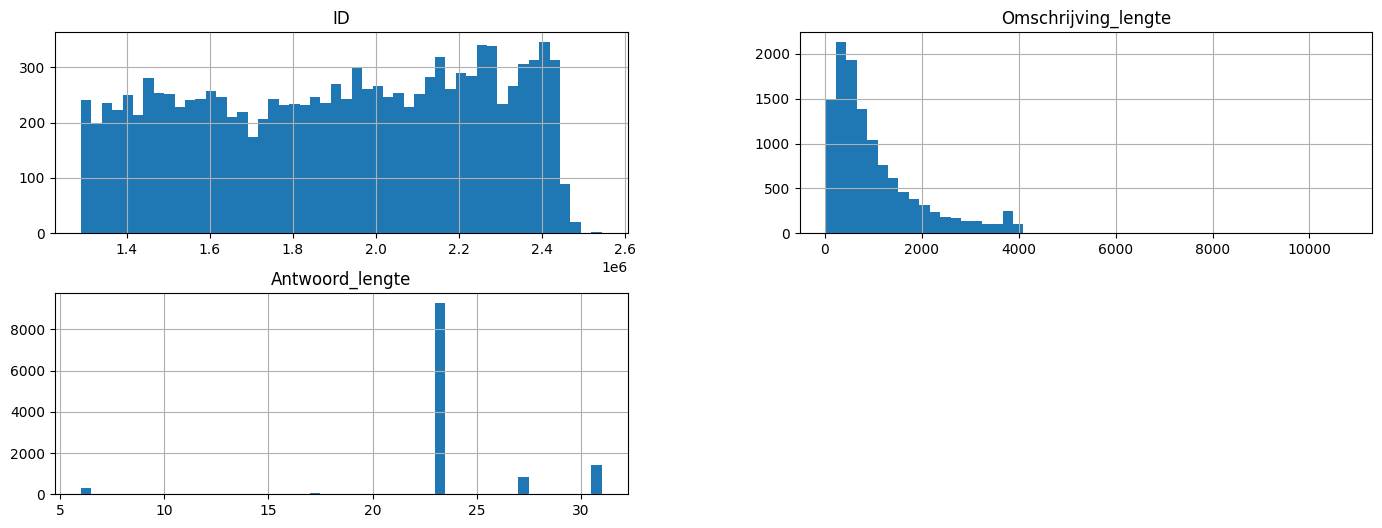

In [13]:
df.hist(bins=50, figsize=(17, 6))
plt.show()

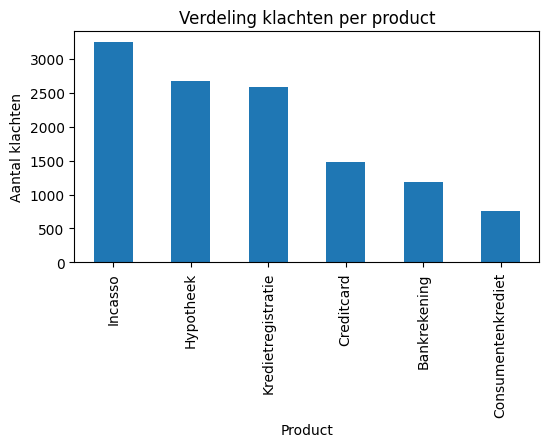

In [14]:
# Bar chart voor Product
plt.figure(figsize=(6,3))
df['Product'].value_counts().plot(kind="bar")
plt.title("Verdeling klachten per product")
plt.xlabel("Product")
plt.ylabel("Aantal klachten")
plt.show()

Incasso ontvangt de meeste klachten

### Analyse per product

### Analyse per specifieke feature